In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

intel = pd.read_csv("../data/raw/INTC_stock_data.csv", parse_dates=["Date"], index_col="Date")
nvidia = pd.read_csv("../data/raw/NVDA_stock_data.csv", parse_dates=["Date"], index_col="Date")

print("Intel data:", intel.shape)
print("NVIDIA data:", nvidia.shape)
print(intel.head())


Intel data: (32, 5)
NVIDIA data: (32, 5)
                         Close                High                 Low  \
Date                                                                     
NaT                       INTC                INTC                INTC   
2025-08-19  25.309999465942383  26.530000686645508  24.940000534057617   
2025-08-20  23.540000915527344   24.93000030517578  23.329999923706055   
2025-08-21                23.5   23.56999969482422  22.780000686645508   
2025-08-22  24.799999237060547  25.229999542236328  23.649999618530273   

                          Open     Volume  
Date                                       
NaT                       INTC       INTC  
2025-08-19  24.940000534057617  297659200  
2025-08-20  24.899999618530273  161149400  
2025-08-21  23.530000686645508   97718300  
2025-08-22  23.649999618530273  200266800  


In [21]:
print("Missing values (Intel):")
print(intel.isna().sum())

print("Missing values (NVIDIA):")
print(nvidia.isna().sum())

Missing values (Intel):
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Missing values (NVIDIA):
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [22]:
event_date = pd.to_datetime("2025-09-17")

intel["EventWindow"] = intel.index.map(lambda x: "Before" if x < event_date else "After")
nvidia["EventWindow"] = nvidia.index.map(lambda x: "Before" if x < event_date else "After")

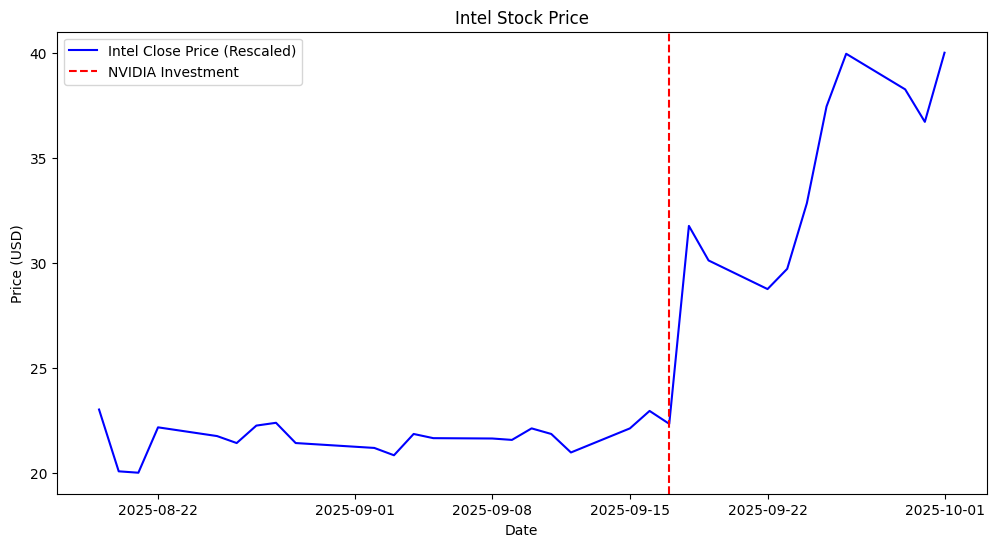

In [33]:
intel["Close"] = pd.to_numeric(intel["Close"], errors="coerce")


intel = intel.dropna(subset=["Close"])


intel_min, intel_max = intel["Close"].min(), intel["Close"].max()

# Stretch/scale data to nearest 5-step axis
scaled_min = 5 * np.floor(intel_min / 5)
scaled_max = 5 * np.ceil(intel_max / 5)

# Create scaling function
def rescale(value, old_min, old_max, new_min, new_max):
    return (value - old_min) / (old_max - old_min) * (new_max - new_min) + new_min

intel_scaled = rescale(intel["Close"], intel_min, intel_max, scaled_min, scaled_max)

# Plot
plt.figure(figsize=(12,6))
plt.plot(intel.index, intel_scaled, label="Intel Close Price (Rescaled)", color="blue")
plt.axvline(event_date, color="red", linestyle="--", label="NVIDIA Investment")

# Set y-axis ticks in increments of 5
plt.yticks(np.arange(scaled_min, scaled_max+5, 5))

plt.title("Intel Stock Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()